# Tramos lineales: cuántos puntos duran y a qué velocidad

La platina barre un triángulo. Sólo una parte de cada pasada va a velocidad constante: es la
única en la que un scan sirve para medir. El cuaderno responde tres cosas.

1. **¿Dónde está el tramo lineal, y cuánto dura?** Se lo busca de dos maneras independientes
   (celda 3): con el **error que mide el controlador** y con una **recta sobre la posición
   medida**. Las dos usan el mismo umbral — un porcentaje del rango de la propia señal — y de
   las dos salen las dos cifras que interesan: **cuántos puntos** dura y **a qué velocidad**
   va la platina ahí.
2. **¿Cuánto se gana bajando el SUD?** (celda 4). SUD son los puntos que el generador gasta
   acelerando y frenando en cada punta.
3. **¿La platina reproduce los escalones de la onda?** (celda 5).

Todo va sobre la grilla de **puntos de la wave** (los píxeles del scan), así que "cuántos
puntos dura el tramo" es una cuenta directa. Ejecutar las celdas en orden.

## Celda 0 — lo necesario

Acceso a los datos, carga de una corrida sobre la grilla de píxeles, y el criterio que
comparten los dos métodos: **en cada pata se mide el rango máx − mín de la señal y se acepta
el tramo contiguo más largo que no se aparta más de `TOL·rango` de la meseta.** El umbral
sale de la propia señal, no se elige a mano.

In [1]:
# =============================================================================
#  CELDA 0 - lo necesario
# =============================================================================
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def buscar_repo():
    for d in (Path.cwd(), *Path.cwd().parents):
        if (d / "datos/raw").is_dir():
            return d
    destino = Path.cwd() / "laboratorio-7"
    if not (destino / "datos/raw").is_dir():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/franaguirreram/laboratorio-7.git",
                        str(destino)], check=True)
    return destino


REPO = buscar_repo()
RAW, META = REPO / "datos/raw", REPO / "datos/metadata"
T_SERVO_US = 39.999984            # [MEDIDO] periodo del lazo de servo del E-517

plt.rcParams.update({"font.family": "serif", "font.size": 9, "figure.dpi": 120,
                     "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5})
C_CMD, C_MED, C_SUD = "0.55", "#1f77b4", "#ff7f0e"
C_ERR, C_RECTA = "#d62728", "#2ca02c"      # un color por metodo


def leer_meta(stem):
    lineas = (META / f"{stem}_metadata.txt").read_text().splitlines()
    return dict(l.split("=", 1) for l in lineas if "=" in l and not l.startswith("#"))


def cargar(stem):
    """Una corrida, reducida a la grilla de PUNTOS de la wave (un valor por pixel).

    El generador mantiene el setpoint quieto WTR ciclos de servo y recien ahi lo
    cambia: ese peldano es el PIXEL del scan. Promediar las muestras de cada
    peldano es exactamente lo que hace un detector integrando sobre el pixel, y
    deja todo el analisis sobre una grilla de n_total puntos: "cuantos puntos
    dura el tramo lineal" pasa a ser una cuenta directa, sin conversiones.
    """
    m = leer_meta(stem)
    df = pd.read_csv(RAW / f"{stem}.csv")
    wtr, rtr, n_pedido = int(m["wtr"]), int(m["rtr"]), int(m["n_total"])
    mpp = max(wtr // rtr, 1)                      # muestras grabadas por punto
    x_cmd = df["target_um"].to_numpy()

    # arranque de la wave, leido del comando; de ahi sale la grilla de puntos
    recorrido = x_cmd.max() - x_cmd.min()
    a = int(np.argmax(np.abs(x_cmd - x_cmd[0]) > recorrido / 1000))
    n = min(n_pedido, (len(x_cmd) - a) // mpp)    # si la wave no entro entera
    pixel = lambda y: y[a:a + n * mpp].reshape(n, mpp).mean(axis=1)

    r = {"stem": stem, "wtr": wtr, "rtr": rtr, "sud": int(m["speedupdown"]),
         "n_total": n_pedido, "n_pt": n, "amplitud_um": float(m["amplitud_um"]),
         "muestras_por_punto": mpp, "arranque": a,
         "dwell_ms": wtr * T_SERVO_US / 1e3,      # lo que dura un punto
         "dt_ms": rtr * T_SERVO_US / 1e3,         # lo que dura una muestra
         "t_ms": np.arange(len(x_cmd)) * rtr * T_SERVO_US / 1e3,
         "x_cmd": x_cmd, "x_med": df["current_um"].to_numpy(),
         "err_nm_crudo": df["error_um"].to_numpy() * 1e3}
    r["k"] = np.arange(n)                          # numero de punto (pixel)
    r["t_pt"] = (a + (np.arange(n) + 0.5) * mpp) * r["dt_ms"]
    r["cmd"], r["med"] = pixel(x_cmd), pixel(r["x_med"])
    r["err"] = pixel(r["err_nm_crudo"])            # error del CONTROLADOR, en nm

    # la ida son los primeros n_total/2 puntos y la vuelta el resto: lo dice el
    # generador, no hace falta buscar el pico (que con SUD > 0 es una meseta)
    h = min(n_pedido // 2, n)
    r["patas"] = {"ida": np.arange(0, h), "vuelta": np.arange(h, n)}

    # SUD = los puntos que el generador gasta acelerando y frenando en cada punta
    sud = r["sud"]
    r["es_sud"] = np.zeros(n, bool)
    for idx in r["patas"].values():
        if len(idx) and sud:
            r["es_sud"][idx[:sud]] = True
            r["es_sud"][idx[-sud:]] = True

    # dx (el tamano del pixel) se MIDE: con SUD > 0 el generador reparte los
    # puntos de forma no uniforme y la cuenta 4*A/n_total ya no vale
    paso = np.abs(np.diff(r["cmd"]))
    r["dx_nm"] = float(np.max(paso) * 1e3)
    return r


def meseta_y_rango(senal, idx):
    """La meseta de una senal dentro de una pata, y su rango max - min.

    Los dos robustos (percentiles 2 y 98, no el maximo y el minimo pelados, que
    son un solo punto y por lo tanto puro ruido). La meseta es el extremo del
    rango del lado donde la senal se queda quieta: como pasa ahi la mayor parte
    de la pata, es el extremo mas cercano a la mediana.
    """
    lo, hi = np.percentile(senal[idx], [2, 98])
    centro = np.median(senal[idx])
    return (hi if abs(hi - centro) < abs(lo - centro) else lo), hi - lo


def tramo_mas_largo(mascara):
    i = np.where(mascara)[0]
    if not len(i):
        return i
    return max(np.split(i, np.where(np.diff(i) > 1)[0] + 1), key=len)


def ajustar(r, idx):
    """Velocidad de la platina en un tramo: pendiente de x_med contra t, con su error."""
    if len(idx) < 3:
        return np.nan, np.nan
    p, cov = np.polyfit(r["t_pt"][idx] * 1e-3, r["med"][idx], 1, cov=True)
    return float(p[0]), float(np.sqrt(cov[0, 0]))


def medir_tramo(r, seg):
    """Lo que se le pide a cada metodo: cuantos puntos y a que velocidad."""
    filas = []
    for cual, idx in seg.items():
        v, dv = ajustar(r, idx)
        filas.append({"pata": cual, "puntos": len(idx),
                      "n_sud": int(r["es_sud"][idx].sum()) if len(idx) else 0,
                      "dur_ms": len(idx) * r["dwell_ms"],
                      "frac_pata": len(idx) / len(r["patas"][cual]),
                      "recorrido_nm": abs(r["med"][idx[-1]] - r["med"][idx[0]]) * 1e3
                                      if len(idx) else np.nan,
                      "v_ajuste_um_s": v, "err_v_um_s": dv})
    return pd.DataFrame(filas)


def por_meseta(r, senal, tol, meseta_en_cero=False):
    """Tramo lineal por tolerancia: donde la senal esta pegada a su meseta.

    En cada pata se mide el rango max - min de la senal y se acepta el tramo
    contiguo mas largo donde la senal no se aparta mas de tol*rango de la meseta.
    El umbral sale de la propia senal, no de un numero elegido a mano.
    Para el residuo a una recta la meseta es el cero (la recta es la referencia).
    """
    seg, ref = {}, {}
    for cual, idx in r["patas"].items():
        m, rango = meseta_y_rango(senal, idx)
        if meseta_en_cero:
            m = 0.0
        seg[cual] = idx[tramo_mas_largo(np.abs(senal[idx] - m) <= tol * rango)]
        ref[cual] = {"meseta": m, "rango": rango, "banda": tol * rango}
    return seg, ref


def residuo_a_la_recta(r, idx, sel=None):
    """Residuo de la posicion medida a una recta, en nm (la recta se ajusta en sel)."""
    t, y = r["t_pt"][idx] * 1e-3, r["med"][idx]
    if sel is None:
        sel = idx
    p = np.polyfit(r["t_pt"][sel] * 1e-3, r["med"][sel], 1)
    return (y - np.polyval(p, t)) * 1e3


def tramo_por_recta(r, tol, n_iter=8):
    """Metodo 2: el tramo lineal es donde una recta todavia describe a la medida.

    La recta de TODA la pata no sirve como criterio: la arrastran las puntas
    curvas y el residuo en el medio queda enorme. Asi que se la usa solo para
    dos cosas — fijar la banda (tol * rango de SUS residuos, en nm, de una vez)
    y arrancar — y despues se reajusta la recta sobre los puntos aceptados hasta
    que el tramo deja de moverse.
    """
    seg, ref = {}, {}
    residuo = np.full(r["n_pt"], np.nan)
    residuo_pata = np.full(r["n_pt"], np.nan)
    for cual, idx in r["patas"].items():
        r0 = residuo_a_la_recta(r, idx)
        banda = tol * np.ptp(r0)
        residuo_pata[idx] = r0
        sel, res = idx, r0
        for _ in range(n_iter):
            res = residuo_a_la_recta(r, idx, sel)
            nuevo = idx[tramo_mas_largo(np.abs(res) <= banda)]
            if len(nuevo) < 3 or np.array_equal(nuevo, sel):
                break
            sel = nuevo
        residuo[idx] = res
        seg[cual] = sel
        ref[cual] = {"meseta": 0.0, "rango": np.ptp(r0), "banda": banda}
    return seg, ref, residuo, residuo_pata


def metodos(r, tol):
    """Los dos metodos sobre una corrida, cada uno con su senal para dibujar."""
    seg_e, ref_e = por_meseta(r, r["err"], tol)
    seg_r, ref_r, res, res_pata = tramo_por_recta(r, tol)
    desvio_e = r["err"] - np.array([ref_e[c]["meseta"] for c in ("ida", "vuelta")]
                                   )[(r["k"] >= len(r["patas"]["ida"])).astype(int)]
    return {"error": {"seg": seg_e, "ref": ref_e, "senal": desvio_e,
                      "etiqueta": "e - e_meseta [nm]", "color": C_ERR,
                      "nombre": "1 · error del controlador"},
            "recta": {"seg": seg_r, "ref": ref_r, "senal": res, "extra": res_pata,
                      "etiqueta": "residuo a la recta [nm]", "color": C_RECTA,
                      "nombre": "2 · recta sobre la medida"}}

## Celda 1 — las corridas que se pueden usar

Modo rampa, `ok=True`, las cuatro columnas necesarias y `RTR = 1` (el recorder graba 8192
muestras cada `RTR` ciclos: mezclar `RTR` es mezclar resoluciones temporales y ventanas).
La columna **`#`** es el número con el que se elige cualquier corrida.

In [2]:
# =============================================================================
#  CELDA 1 - las corridas de rampa que se pueden usar
# =============================================================================
# Util = modo rampa, ok=True, las cuatro columnas que hace falta y RTR = 1 (el
# recorder graba 8192 muestras cada RTR ciclos: mezclar RTR es mezclar
# resoluciones temporales y ventanas en la misma tabla).
COLUMNAS = {"t_ms", "target_um", "current_um", "error_um"}

filas = []
for csv in sorted(RAW.glob("E517_rampa_*.csv")):
    try:
        m = leer_meta(csv.stem)
        cabecera = set(csv.open().readline().strip().split(","))
    except OSError:
        continue
    if (m.get("modo"), m.get("ok"), m.get("rtr")) != ("rampa", "True", "1"):
        continue
    if not COLUMNAS <= cabecera:
        continue
    filas.append({"stem": csv.stem, "amplitud_um": float(m["amplitud_um"]),
                  "n_total": int(m["n_total"]), "wtr": int(m["wtr"]),
                  "sud": int(m["speedupdown"])})

RAMPAS = (pd.DataFrame(filas)
          .sort_values(["amplitud_um", "n_total", "wtr", "sud", "stem"])
          .reset_index(drop=True))
# dx = el pixel: la excursion 2A repartida entre los n_total/2 puntos de una pata
RAMPAS["dx_nm"] = 4e3 * RAMPAS.amplitud_um / RAMPAS.n_total
RAMPAS["dwell_ms"] = RAMPAS.wtr * T_SERVO_US / 1e3
RAMPAS["v_um_s"] = RAMPAS.dx_nm / 1e3 / (RAMPAS.dwell_ms * 1e-3)
RAMPAS["wave_ms"] = RAMPAS.n_total * RAMPAS.dwell_ms
RAMPAS.index.name = "#"

print(f"{len(RAMPAS)} corridas utiles (RTR = 1, ventana {8192*T_SERVO_US/1e3:.1f} ms) · "
      f"WTR {sorted(map(int, RAMPAS.wtr.unique()))} · "
      f"SUD {sorted(map(int, RAMPAS.sud.unique()))} · "
      f"amplitudes {sorted(map(float, RAMPAS.amplitud_um.unique()))} um")
print(f"{(RAMPAS.wave_ms > 8192*T_SERVO_US/1e3).sum()} con la wave mas larga que la ventana "
      f"(quedan cortadas)")
display(RAMPAS[["stem", "amplitud_um", "n_total", "wtr", "sud", "dx_nm", "v_um_s"]])

91 corridas utiles (RTR = 1, ventana 327.7 ms) · WTR [5, 10, 20] · SUD [0, 10, 20, 40, 80] · amplitudes [0.05, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0] um
2 con la wave mas larga que la ventana (quedan cortadas)


,stem,amplitud_um,n_total,wtr,sud,dx_nm,v_um_s
#,,,,,,,
0,E517_rampa_tau_A0.05um_20260909_154848_r0,0.05,400,20,0,0.5,0.625000
1,E517_rampa_tau_A0.05um_20260909_154853_r1,0.05,400,20,0,0.5,0.625000
2,E517_rampa_tau_A0.1um_20260909_154858_r0,0.10,400,20,0,1.0,1.250001
3,E517_rampa_tau_A0.1um_20260909_154903_r1,0.10,400,20,0,1.0,1.250001
4,E517_rampa_tau_A0.1um_20260909_155116_r0,0.10,400,20,0,1.0,1.250001
...,...,...,...,...,...,...,...
86,E517_rampa_tau_A30um_20260909_170304_r1,30.00,400,20,0,300.0,375.000150
87,E517_rampa_tau_A30um_20260909_174146_r0,30.00,400,20,0,300.0,375.000150
88,E517_rampa_tau_A30um_20260909_174151_r1,30.00,400,20,0,300.0,375.000150


## Celda 2 — la onda, y los puntos que se gastan en las puntas

La comandada, la medida encima (se ve el atraso del lazo) y en naranja los **puntos SUD**,
los que el generador gasta acelerando y frenando. Se pagan en tiempo y no sirven para medir.
Cambiando `CORRIDA` acá corren con otra medición las celdas 2 y 3.

E517_rampa_scan_w10_sud40_20260907_172930_r0
  amplitud 1.0 um · 400 puntos · WTR 10 (400 us por punto) · SUD 40 · dx 12.7 nm
  SUD: 160 de 400 puntos (40%) se gastan acelerando y frenando en las puntas


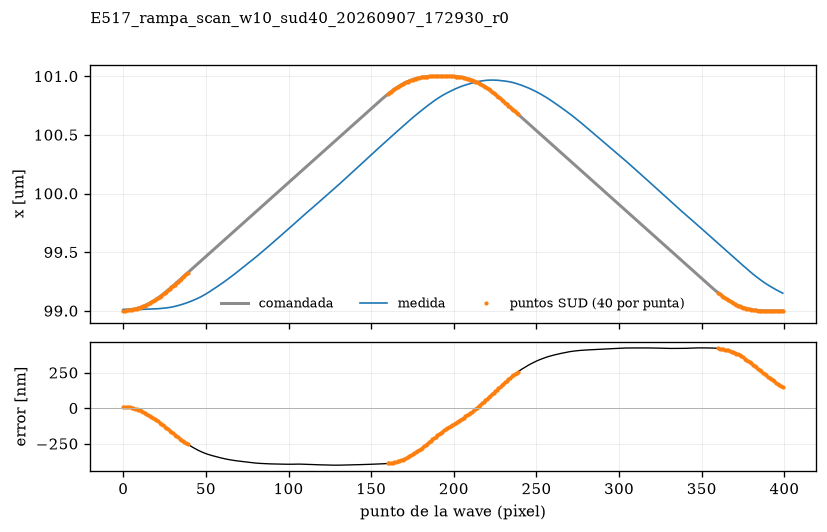

In [3]:
# =============================================================================
#  CELDA 2 - la onda: lo que se comanda, lo que hace la platina y los puntos SUD
# =============================================================================
CORRIDA = "E517_rampa_scan_w10_sud40_20260907_172930_r0"

r = cargar(CORRIDA)
print(f"{CORRIDA}\n  amplitud {r['amplitud_um']} um · {r['n_pt']} puntos · WTR {r['wtr']} "
      f"({r['dwell_ms']*1e3:.0f} us por punto) · SUD {r['sud']} · dx {r['dx_nm']:.1f} nm")
print(f"  SUD: {r['es_sud'].sum()} de {r['n_pt']} puntos ({r['es_sud'].mean():.0%}) se gastan "
      f"acelerando y frenando en las puntas")

fig, ax = plt.subplots(2, 1, figsize=(7.8, 4.4), sharex=True,
                       gridspec_kw=dict(height_ratios=[2, 1], hspace=0.1))
ax[0].plot(r["k"], r["cmd"], color=C_CMD, lw=1.8, label="comandada")
ax[0].plot(r["k"], r["med"], color=C_MED, lw=1.0, label="medida")
ax[0].plot(r["k"][r["es_sud"]], r["cmd"][r["es_sud"]], ".", color=C_SUD, ms=3,
           label=f"puntos SUD ({r['sud']} por punta)")
ax[0].set_ylabel("x [um]")
ax[0].legend(frameon=False, ncol=3, loc="lower center", fontsize=8)

ax[1].plot(r["k"], r["err"], color="k", lw=0.8)
ax[1].plot(r["k"][r["es_sud"]], r["err"][r["es_sud"]], ".", color=C_SUD, ms=3)
ax[1].axhline(0, color="0.7", lw=0.6)
ax[1].set_ylabel("error [nm]")
ax[1].set_xlabel("punto de la wave (pixel)")
fig.suptitle(f"{CORRIDA}", fontsize=9, x=0.125, ha="left", y=0.98)
plt.show()

## Celda 3 — el tramo lineal, por dos señales independientes

**Método 1 — el error del controlador.** En una rampa el lazo se atrasa una cantidad fija,
`e = −v·τ`: el error sube hasta una meseta durante la ida y hasta la opuesta en la vuelta.
Esa meseta *es* el tramo lineal, y su altura da `τ = |e|/v`.

**Método 2 — una recta sobre la posición medida.** Pregunta directamente hasta dónde la
posición medida es una recta en el tiempo.

> Un detalle que cambia el resultado: la recta ajustada sobre **toda** la pata no sirve como
> criterio, porque la arrastran las puntas curvas — es la curva gris del panel (c), que se va
> a ±150 nm en el medio del tramo. Se la usa sólo para fijar la banda y para arrancar, y
> después se reajusta la recta sobre los puntos aceptados hasta que el tramo deja de moverse.

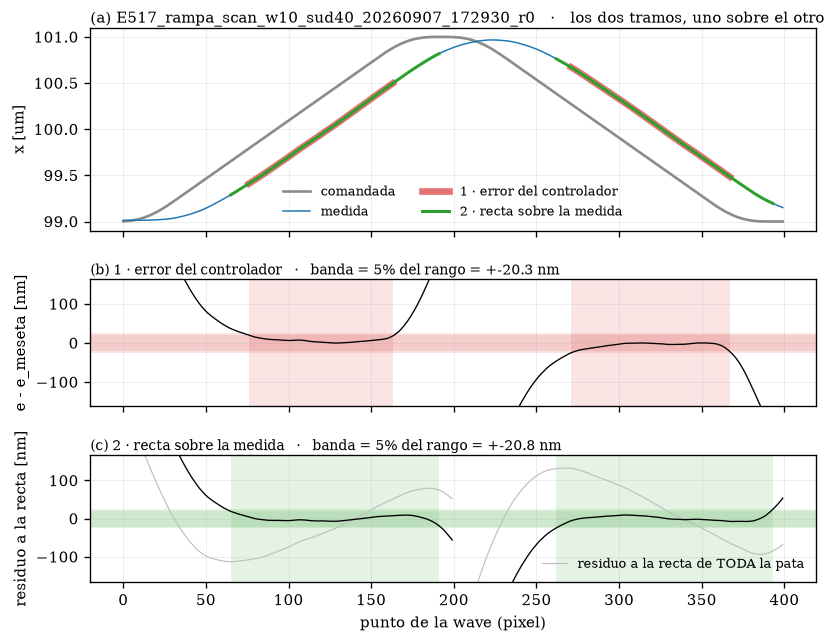

,metodo,pata,puntos,n_sud,frac_pata,dur_ms,recorrido_nm,v_ajuste_um_s,err_v_um_s
0,1 · error del controlador,ida,88,4,0.440,35.2,1085.0,31.30,0.04
1,1 · error del controlador,vuelta,97,8,0.485,38.8,1186.0,-31.09,0.04
2,2 · recta sobre la medida,ida,127,32,0.635,50.8,1529.0,31.09,0.04
3,2 · recta sobre la medida,vuelta,132,34,0.660,52.8,1566.0,-30.82,0.04



velocidad comandada 31.75 um/s  ·  ajustada 31.30 (error) y 31.09 um/s (recta): difieren 0.7%
meseta del error -401 nm  ->  tau = |e|/v = 12.8 ms


In [4]:
# =============================================================================
#  CELDA 3 - el tramo lineal, por dos senales independientes
# =============================================================================
# Los dos metodos hacen la misma pregunta con el mismo umbral: en cada pata se
# mide el RANGO max - min de una senal y se acepta el tramo contiguo mas largo
# que no se aparta mas de TOL*rango de la meseta. El umbral sale de la senal, no
# se elige a mano.
#
#   1 - ERROR DEL CONTROLADOR. En una rampa el lazo se atrasa una cantidad fija,
#       e = -v*tau: el error arranca en cero, sube hasta una meseta durante la
#       ida y baja hasta la opuesta en la vuelta. Esa meseta ES el tramo lineal,
#       y de yapa da tau = |e|/v. Es la senal que mide el propio controlador.
#
#   2 - RECTA SOBRE LA POSICION MEDIDA. Pregunta directamente lo que importa:
#       hasta donde la posicion medida es una recta en el tiempo. Ojo con esto:
#       la recta ajustada sobre TODA la pata NO sirve como criterio, porque la
#       arrastran las puntas curvas (gris en el panel (c)). Se la usa solo para
#       fijar la banda y arrancar, y despues se reajusta sobre lo aceptado.
TOL = 0.05

M = metodos(r, TOL)

fig, ax = plt.subplots(3, 1, figsize=(7.8, 6.0), sharex=True,
                       gridspec_kw=dict(height_ratios=[1.6, 1, 1], hspace=0.32))
ax[0].plot(r["k"], r["cmd"], color=C_CMD, lw=1.6, label="comandada")
ax[0].plot(r["k"], r["med"], color=C_MED, lw=0.9, label="medida")
for m, ancho in ((M["error"], 4.0), (M["recta"], 1.8)):
    for cual, idx in m["seg"].items():
        if len(idx):
            ax[0].plot(r["k"][idx], r["med"][idx], color=m["color"], lw=ancho,
                       alpha=0.65 if ancho > 3 else 1.0,
                       label=m["nombre"] if cual == "ida" else None)
ax[0].set_ylabel("x [um]")
ax[0].legend(frameon=False, ncol=2, loc="lower center", fontsize=8)
ax[0].set_title(f"(a) {CORRIDA}   ·   los dos tramos, uno sobre el otro",
                fontsize=9, loc="left", pad=3)

for j, clave in enumerate(("error", "recta"), start=1):
    m = M[clave]
    for cual, pata in r["patas"].items():
        if clave == "recta":
            ax[j].plot(r["k"][pata], m["extra"][pata], color="0.75", lw=0.7,
                       label="residuo a la recta de TODA la pata"
                             if cual == "ida" else None)
        ax[j].plot(r["k"][pata], m["senal"][pata], color="k", lw=0.8)
    for cual, idx in m["seg"].items():
        b = m["ref"][cual]["banda"]
        ax[j].axhspan(-b, b, color=m["color"], alpha=0.12, lw=0)
        if len(idx):
            ax[j].axvspan(idx[0], idx[-1], color=m["color"], alpha=0.12, lw=0)
    ax[j].set_ylabel(m["etiqueta"])
    b = M[clave]["ref"]["ida"]["banda"]
    ax[j].set_ylim(-8 * b, 8 * b)
    ax[j].set_title(f"({'bc'[j-1]}) {m['nombre']}   ·   banda = {TOL:.0%} del rango "
                    f"= +-{b:.1f} nm", fontsize=8.5, loc="left", pad=3)
    if clave == "recta":
        ax[j].legend(frameon=False, fontsize=7.5, loc="lower right")
ax[2].set_xlabel("punto de la wave (pixel)")
plt.show()

TABLA = pd.concat([medir_tramo(r, m["seg"]).assign(metodo=m["nombre"])
                   for m in M.values()], ignore_index=True)
display(TABLA[["metodo", "pata", "puntos", "n_sud", "frac_pata", "dur_ms",
               "recorrido_nm", "v_ajuste_um_s", "err_v_um_s"]]
        .round({"frac_pata": 3, "dur_ms": 2, "recorrido_nm": 0,
                "v_ajuste_um_s": 2, "err_v_um_s": 2}))

e0 = M["error"]["ref"]["ida"]["meseta"]
v = TABLA.query("pata == 'ida'").v_ajuste_um_s
print(f"\nvelocidad comandada {r['dx_nm']/r['dwell_ms']:.2f} um/s  ·  ajustada "
      f"{v.iloc[0]:.2f} (error) y {v.iloc[1]:.2f} um/s (recta): difieren "
      f"{abs(v.iloc[0]-v.iloc[1])/abs(v.mean()):.1%}")
print(f"meseta del error {e0:+.0f} nm  ->  tau = |e|/v = "
      f"{abs(e0)/1e3/abs(v.iloc[0])*1e3:.1f} ms")

## Celda 4 — el mismo análisis en otras mediciones: bajar el SUD

Corridas que sólo difieren en SUD, con los dos métodos corridos sobre cada una. Al leer la
tabla hay que tener presente que con `SUD > 0` el generador reparte los puntos de forma no
uniforme, así que `dx` y la velocidad suben aunque no se haya tocado WTR: los dos efectos
empujan para el mismo lado.

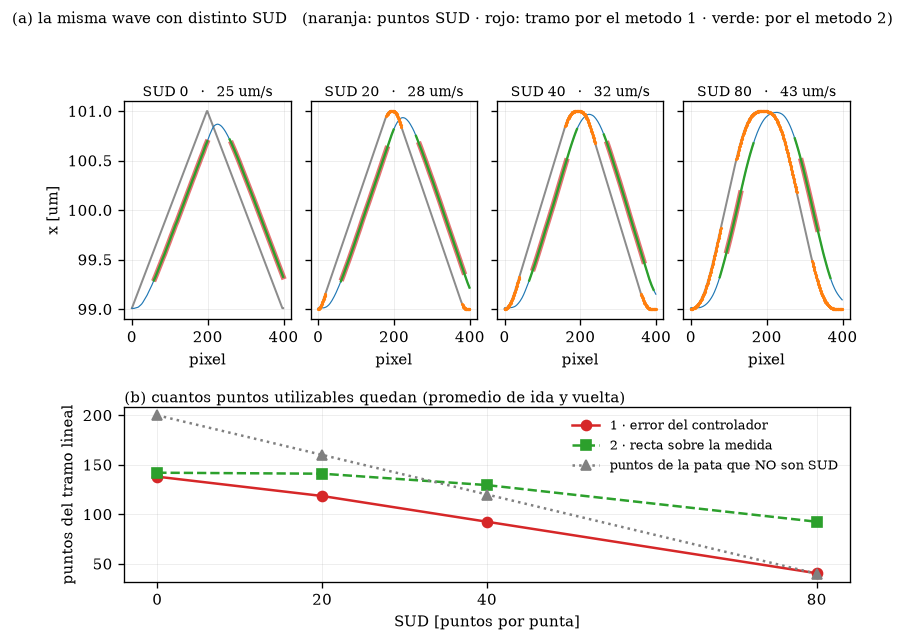

,sud,dx_nm,v_cmd_um_s,puntos_error,frac_error,v_error,puntos_recta,frac_recta,v_recta
0,0,10.1,25.25,138.0,0.69,25.01,142.0,0.71,24.96
1,20,11.2,28.00,118.5,0.59,27.78,141.0,0.70,27.74
2,40,12.7,31.75,92.5,0.46,31.19,129.5,0.65,30.95
3,80,17.2,43.00,40.5,0.20,40.53,92.5,0.46,39.27



de SUD 80 a SUD 0 el tramo lineal pasa de 40 a 138 puntos (20% a 69% de la pata). Los puntos de punta no
solo no se usan: ademas suben dx de 10.1 a 17.2 nm y la velocidad de 25 a 43 um/s, y cuanto mas rapido
va la platina mas tarda en enganchar.


In [5]:
# =============================================================================
#  CELDA 4 - el mismo analisis en otras mediciones: que pasa al bajar el SUD
# =============================================================================
# SUD = los puntos que el generador gasta acelerando y frenando en cada punta.
# Se comparan corridas que solo difieren en SUD, con los dos metodos de la celda
# 3 corridos sobre cada una.
#
# Trampa a tener presente al leer la tabla: con SUD > 0 el generador reparte los
# n_total puntos de forma NO uniforme (gasta puntos en las puntas y los del medio
# quedan mas separados), asi que dx y con el la velocidad suben aunque no se haya
# tocado WTR. Los dos efectos empujan para el mismo lado, por eso van las cuatro
# columnas juntas.
FAMILIA_SUD = dict(amplitud_um=1.0, n_total=400, wtr=10)

sel = (RAMPAS.query(" and ".join(f"{k} == {v}" for k, v in FAMILIA_SUD.items()))
       .drop_duplicates("sud").sort_values("sud"))
casos = [(cargar(s), metodos(cargar(s), TOL)) for s in sel.stem]

fig = plt.figure(figsize=(7.8, 5.2))
gs = fig.add_gridspec(2, len(casos), height_ratios=[1.25, 1], hspace=0.45, wspace=0.12)
for j, (rc, Mc) in enumerate(casos):
    a = fig.add_subplot(gs[0, j], sharey=None if j == 0 else fig.axes[0])
    a.plot(rc["k"], rc["cmd"], color=C_CMD, lw=1.2)
    a.plot(rc["k"], rc["med"], color=C_MED, lw=0.7)
    a.plot(rc["k"][rc["es_sud"]], rc["cmd"][rc["es_sud"]], ".", color=C_SUD, ms=1.8)
    for m, ancho in ((Mc["error"], 3.2), (Mc["recta"], 1.4)):
        for idx in m["seg"].values():
            if len(idx):
                a.plot(rc["k"][idx], rc["med"][idx], color=m["color"], lw=ancho,
                       alpha=0.65 if ancho > 3 else 1.0)
    a.set_title(f"SUD {rc['sud']}   ·   {rc['dx_nm']/rc['dwell_ms']:.0f} um/s",
                fontsize=8.5, pad=3)
    a.set_xlabel("pixel")
    a.tick_params(labelleft=(j == 0))
    if j == 0:
        a.set_ylabel("x [um]")
fig.text(0.005, 1.005, "(a) la misma wave con distinto SUD   (naranja: puntos SUD · "
         "rojo: tramo por el metodo 1 · verde: por el metodo 2)", fontsize=9, ha="left")

abajo = fig.add_subplot(gs[1, :])
suds = [rc["sud"] for rc, _ in casos]
for clave, marca in (("error", "o-"), ("recta", "s--")):
    y = [np.mean([len(i) for i in Mc[clave]["seg"].values()]) for _, Mc in casos]
    abajo.plot(suds, y, marca, color=casos[0][1][clave]["color"],
               label=casos[0][1][clave]["nombre"])
abajo.plot(suds, [len(rc["patas"]["ida"]) - rc["sud"] * 2 for rc, _ in casos], "^:",
           color="0.5", label="puntos de la pata que NO son SUD")
abajo.set_xticks(suds)
abajo.set_xlabel("SUD [puntos por punta]")
abajo.set_ylabel("puntos del tramo lineal")
abajo.legend(frameon=False, fontsize=8)
abajo.set_title("(b) cuantos puntos utilizables quedan (promedio de ida y vuelta)",
                fontsize=9, loc="left", pad=3)
plt.show()

filas = []
for rc, Mc in casos:
    f = {"sud": rc["sud"], "dx_nm": rc["dx_nm"],
         "v_cmd_um_s": rc["dx_nm"] / rc["dwell_ms"]}
    for clave, Mm in Mc.items():
        d = medir_tramo(rc, Mm["seg"])
        f[f"puntos_{clave}"] = d.puntos.mean()
        f[f"frac_{clave}"] = d.frac_pata.mean()
        f[f"v_{clave}"] = d.v_ajuste_um_s.abs().mean()
    filas.append(f)
COMPARA_SUD = pd.DataFrame(filas)
display(COMPARA_SUD.round(2))

mejor, peor = COMPARA_SUD.iloc[0], COMPARA_SUD.iloc[-1]
print(f"\nde SUD {peor.sud:.0f} a SUD {mejor.sud:.0f} el tramo lineal pasa de "
      f"{peor.puntos_error:.0f} a {mejor.puntos_error:.0f} puntos "
      f"({peor.frac_error:.0%} a {mejor.frac_error:.0%} de la pata). Los puntos de punta no\n"
      f"solo no se usan: ademas suben dx de {mejor.dx_nm:.1f} a {peor.dx_nm:.1f} nm y la "
      f"velocidad de {mejor.v_cmd_um_s:.0f} a {peor.v_cmd_um_s:.0f} um/s, y cuanto mas rapido\n"
      f"va la platina mas tarda en enganchar.")

## Celda 5 — el escalonamiento

El generador no comanda una rampa sino una **escalera** de peldaños de `dx` nm. La pregunta
es si la platina los reproduce (y entonces el píxel es una parada) o si los barre de corrido
(y entonces el píxel lo define el dwell). El zoom se toma en el medio del tramo lineal y a la
medida se le resta el atraso del lazo, que si no queda un micrón más abajo.

amplitud 1.0 um · n_total 400 · SUD 80 · dx 17.2 nm · WTR = [5, 10, 20]

  WTR  5 ( 200 us/pt): peldanos de 17.2 nm  ->  a la platina le queda una ondulacion de 0.10 nm rms (0.6% del peldano)
  WTR 10 ( 400 us/pt): peldanos de 17.2 nm  ->  a la platina le queda una ondulacion de 0.08 nm rms (0.5% del peldano)
  WTR 20 ( 800 us/pt): peldanos de 17.2 nm  ->  a la platina le queda una ondulacion de 0.26 nm rms (1.5% del peldano)


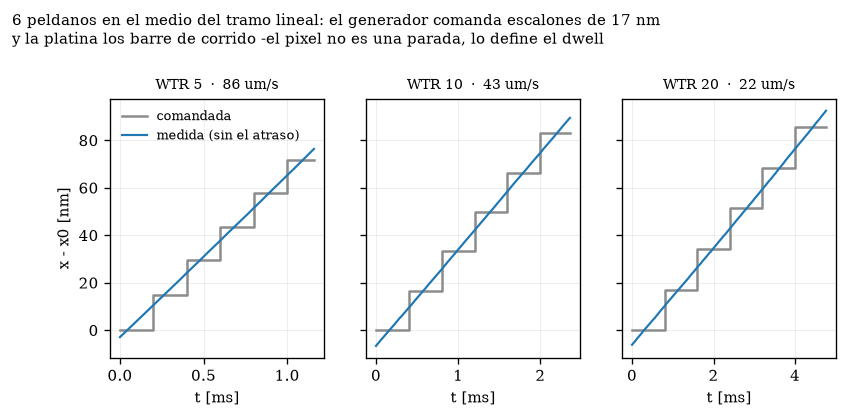

In [6]:
# =============================================================================
#  CELDA 5 - el escalonamiento: que queda del escalon en la platina
# =============================================================================
# WTR = cuantos ciclos de servo (40 us) dura cada punto. Con la amplitud, n_total
# y SUD fijos el pixel dx no cambia: WTR es, literal, la perilla de la velocidad.
# (Hay tambien corridas de WTR 40 y 80, todas grabadas con RTR = 4, que la celda
# 1 deja afuera para no mezclar resoluciones temporales.)
#
# Para que sirve esta figura: el generador no comanda una rampa, comanda una
# ESCALERA de peldanos de dx nm. La pregunta es si la platina los reproduce (y
# entonces el pixel es una parada, con la platina quieta mientras se integra) o
# si los barre de corrido (y entonces el pixel es un barrido de dx nm y lo que
# lo define es el dwell). El zoom se toma en el medio del tramo lineal, y a la
# medida se le resta el atraso del lazo -de otro modo queda un micron mas abajo
# y no se pueden comparar las formas.
FAMILIA_WTR = dict(amplitud_um=1.0, n_total=400, sud=80)
N_PELDANOS = 6

sel = (RAMPAS.query(" and ".join(f"{k} == {v}" for k, v in FAMILIA_WTR.items()))
       .drop_duplicates("wtr").sort_values("wtr"))
corridas = [cargar(s) for s in sel.stem]
print(f"amplitud {FAMILIA_WTR['amplitud_um']} um · n_total {FAMILIA_WTR['n_total']} · "
      f"SUD {FAMILIA_WTR['sud']} · dx {corridas[0]['dx_nm']:.1f} nm · "
      f"WTR = {[c['wtr'] for c in corridas]}\n")

fig, ax = plt.subplots(1, len(corridas), figsize=(7.8, 2.8), sharey=True)
for j, c in enumerate(corridas):
    tramo = metodos(c, TOL)["error"]["seg"]["ida"]          # el medio del tramo lineal
    k0 = int(np.median(tramo)) - N_PELDANOS // 2
    i = np.arange(c["arranque"] + k0 * c["muestras_por_punto"],
                  c["arranque"] + (k0 + N_PELDANOS) * c["muestras_por_punto"])
    t = c["t_ms"][i] - c["t_ms"][i[0]]
    cmd = (c["x_cmd"][i] - c["x_cmd"][i[0]]) * 1e3
    med = (c["x_med"][i] - c["x_cmd"][i[0]]) * 1e3
    med -= np.median(med - cmd)                             # le saca el atraso v*tau
    sobra = (med - np.polyval(np.polyfit(t, med, 1), t))
    ax[j].step(t, cmd, where="post", color=C_CMD, lw=1.5, label="comandada")
    ax[j].plot(t, med, color=C_MED, lw=1.3, label="medida (sin el atraso)")
    ax[j].set_title(f"WTR {c['wtr']}  ·  {c['dx_nm']/c['dwell_ms']:.0f} um/s", fontsize=8.5)
    ax[j].set_xlabel("t [ms]")
    print(f"  WTR {c['wtr']:2d} ({c['dwell_ms']*1e3:4.0f} us/pt): peldanos de "
          f"{c['dx_nm']:.1f} nm  ->  a la platina le queda una ondulacion de "
          f"{np.std(sobra):.2f} nm rms ({np.std(sobra)/c['dx_nm']:.1%} del peldano)")
ax[0].set_ylabel("x - x0 [nm]")
ax[0].legend(frameon=False, fontsize=7.5, loc="upper left")
fig.suptitle(f"{N_PELDANOS} peldanos en el medio del tramo lineal: el generador comanda "
             f"escalones de {corridas[0]['dx_nm']:.0f} nm\ny la platina los barre de corrido "
             f"-el pixel no es una parada, lo define el dwell", fontsize=9, x=0.02,
             ha="left", y=1.14)
plt.show()